In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# =====================
# 1. Load Dataset
# =====================
df = pd.read_csv("diabetes1.csv")  # Replace with your dataset path

# =====================
# 2. Basic Cleaning
# =====================
# Replace missing values if any
df = df.replace(['?', 'NA', 'NaN', None], np.nan)

# Fill missing numerical columns with median for robustness
for col in df.columns:
    if df[col].dtype != 'object':
        df[col].fillna(df[col].median(), inplace=True)

# =====================
# 3. Feature Encoding (if needed)
# =====================
# If categorical columns exist (like 'Sex' or 'Smoker'), encode them
categorical_cols = df.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# =====================
# 4. Feature-Target Split
# =====================
target = 'Diabetes_012'
X = df.drop(columns=[target])
y = df[target]

# =====================
# 5. Train-Test Split
# =====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# =====================
# 6. Scaling + Oversampling + Modeling Pipeline
# =====================
scaler = StandardScaler()
smote = SMOTE(random_state=42)

# Base models
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42)
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42)

# Ensemble: Soft voting (averages predicted probabilities)
ensemble = VotingClassifier(
    estimators=[('xgb', xgb), ('rf', rf), ('lgbm', lgbm), ('gb', gb)],
    voting='soft'
)

# =====================
# 7. Build Final Pipeline
# =====================
pipeline = Pipeline([
    ('scaler', scaler),
    ('smote', smote),
    ('ensemble', ensemble)
])

# =====================
# 8. Train Model
# =====================
pipeline.fit(X_train, y_train)

# =====================
# 9. Evaluate
# =====================
y_pred = pipeline.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

# =====================
# 10. Cross-Validation
# =====================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
print(f"\nCross-Validation Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

C:\Users\hirde\AppData\Local\Temp\ipykernel_4980\1852490566.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\hirde\AppData\Local\Temp\ipykernel_4980\1852490566.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037231 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4637
[LightGBM] [Info] Number of data points in the train set: 512886, number of used features: 21
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packa


Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.94      0.91     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.48      0.34      0.40      7069

    accuracy                           0.84     50736
   macro avg       0.46      0.43      0.44     50736
weighted avg       0.81      0.84      0.82     50736

Accuracy: 0.8427743614001892


c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:18:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:15:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037912 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4639
[LightGBM] [Info] Number of data points in the train set: 512886, number of used features: 21
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:45:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043715 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4484
[LightGBM] [Info] Number of data points in the train set: 512889, number of used features: 21
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


KeyboardInterrupt: 

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import VotingClassifier

# ============== Load Data ==============
df = pd.read_csv("diabetes1.csv")

# Fix missing
df.replace(['?', 'NA', 'NaN', None], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# Encode categorical columns
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# 🧩 OPTION A: Merge into binary
df['Diabetes_012'] = df['Diabetes_012'].replace({1: 1, 2: 1})

# ============== Split ==============
X = df.drop(columns=['Diabetes_012'])
y = df['Diabetes_012']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ============== SMOTE ==============
smote = SMOTE(sampling_strategy=0.3, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# ============== Scale ==============
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# ============== Ensemble ==============
xgb = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8, random_state=42)
lgbm = LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=42)

ensemble = VotingClassifier(
    estimators=[('xgb', xgb), ('lgbm', lgbm)],
    voting='soft'
)

# Train + Evaluate
ensemble.fit(X_train_res, y_train_res)
preds = ensemble.predict(X_test_scaled)

print("\nAccuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))


[LightGBM] [Info] Number of positive: 51288, number of negative: 170962
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018226 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4874
[LightGBM] [Info] Number of data points in the train set: 222250, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.230767 -> initscore=-1.203985
[LightGBM] [Info] Start training from score -1.203985

Accuracy: 0.8506583096814885
              precision    recall  f1-score   support

         0.0       0.87      0.97      0.92     42741
         1.0       0.56      0.23      0.33      7995

    accuracy                           0.85     50736
   macro avg       0.72      0.60      0.62     50736
weighted avg       0.82      0.85      0.82     50736



c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [32]:
import joblib

# ============== Save Model ==============
joblib.dump(ensemble, "diabetes_ensemble_model.pkl")

print("\n✅ Model saved successfully as 'diabetes_ensemble_model.pkl'")



✅ Model saved successfully as 'diabetes_ensemble_model.pkl'


In [33]:
import joblib

# Load model
ensemble_loaded = joblib.load("diabetes_ensemble_model.pkl")

# Example: use it to predict again
preds = ensemble_loaded.predict(X_test_scaled)
print("Reloaded Model Accuracy:", accuracy_score(y_test, preds))


c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


ValueError: Found input variables with inconsistent numbers of samples: [154, 50736]

In [36]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# === Load and preprocess data ===
df = pd.read_csv("diabetes1.csv")
df.replace(['?', 'NA', 'NaN', None], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# Encode categorical columns
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

df['Diabetes_012'] = df['Diabetes_012'].replace({1: 1, 2: 1})

X = df.drop(columns=['Diabetes_012'])
y = df['Diabetes_012']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# === Define Models ===
xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8, random_state=42)
lgbm = LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=42)

ensemble = VotingClassifier(
    estimators=[('xgb', xgb), ('lgbm', lgbm)],
    voting='soft'
)

# === Pipeline (Scaler + SMOTE + Model) ===
pipeline = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('smote', SMOTE(sampling_strategy=0.3, random_state=42)),
    ('model', ensemble)
])

# === Train ===
pipeline.fit(X_train, y_train)

# === Evaluate ===
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("\n✅ Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

# === Save entire pipeline ===
joblib.dump(pipeline, "diabetes_full_pipeline.pkl")
print("\n💾 Saved full pipeline as 'diabetes_full_pipeline.pkl'")


c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



✅ Model Performance:
Accuracy: 0.8520971302428256
ROC AUC: 0.8244913737073833
              precision    recall  f1-score   support

         0.0       0.87      0.97      0.92     42741
         1.0       0.58      0.23      0.33      7995

    accuracy                           0.85     50736
   macro avg       0.72      0.60      0.62     50736
weighted avg       0.82      0.85      0.82     50736


💾 Saved full pipeline as 'diabetes_full_pipeline.pkl'


In [37]:
import joblib
import pandas as pd

# === Load saved pipeline ===
pipeline = joblib.load("diabetes_full_pipeline.pkl")

# === Load new or same dataset ===
df = pd.read_csv("diabetes1.csv")

# Drop label for new data
X_new = df.drop(columns=['Diabetes_012'])

# === Predict ===
preds = pipeline.predict(X_new)
print("Predictions:", preds[:10])


c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Predictions: [1. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


In [9]:
selected_features = [
    'HighBP', 'HighChol', 'BMI', 'Stroke', 'HeartDiseaseorAttack',
    'PhysActivity', 'Fruits', 'Veggies', 'GenHlth', 'PhysHlth',
    'DiffWalk', 'Age'
]


In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import VotingClassifier
from imblearn.over_sampling import SMOTE

# ===== Load & Clean =====
df = pd.read_csv("diabetes1.csv")
df.replace(['?', 'NA', 'NaN', None], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# ===== Convert categorical =====
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# ===== Binary conversion =====
df['Diabetes_012'] = df['Diabetes_012'].replace({1: 1, 2: 1})

# ===== Feature selection =====
selected_features = [
    'HighBP', 'HighChol', 'BMI', 'Stroke', 'HeartDiseaseorAttack',
    'PhysActivity', 'Fruits', 'Veggies', 'GenHlth', 'PhysHlth',
    'DiffWalk', 'Age'
]
X = df[selected_features]
y = df['Diabetes_012']

# ===== Split =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ===== Balance =====
smote = SMOTE(sampling_strategy=0.3, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# ===== Scale =====
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# ===== Weighted Ensemble =====
xgb = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(len(y_train_res) - sum(y_train_res)) / sum(y_train_res),
    random_state=42
)

lgbm = LGBMClassifier(
    n_estimators=200, learning_rate=0.05,
    class_weight='balanced',
    random_state=42
)

ensemble = VotingClassifier(
    estimators=[('xgb', xgb), ('lgbm', lgbm)],
    voting='soft'
)

# ===== Train & Evaluate =====
ensemble.fit(X_train_res, y_train_res)
probs = ensemble.predict_proba(X_test_scaled)[:, 1]
preds = (probs > 0.35).astype(int)

print("\nAccuracy:", accuracy_score(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))
print("F1 Score:", f1_score(y_test, preds))
print("\nClassification Report:\n", classification_report(y_test, preds))


[LightGBM] [Info] Number of positive: 51288, number of negative: 170962
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012486 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3043
[LightGBM] [Info] Number of data points in the train set: 222250, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Accuracy: 0.6591769157994324
ROC AUC: 0.8175191061292886
F1 Score: 0.43889934453890583

Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      0.62      0.76     42741
         1.0       0.30      0.85      0.44      7995

    accuracy                           0.66     50736
   macro avg       0.63      0.74      0.60     50736
weighted avg       0.85      0.66      0.71     50736



In [11]:
df['BMI_Age'] = df['BMI'] * df['Age']
df['Health_Index'] = df['GenHlth'] * df['PhysHlth']
df['BP_Chol'] = df['HighBP'] * df['HighChol']


In [12]:
selected_features += ['BMI_Age', 'Health_Index', 'BP_Chol']


In [13]:
from sklearn.metrics import f1_score
import numpy as np

best_t, best_f1 = 0, 0
for t in np.arange(0.1, 0.9, 0.01):
    preds = (probs > t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1, best_t = f1, t

print(f"Best Threshold: {best_t:.2f}, Best F1: {best_f1:.4f}")


Best Threshold: 0.55, Best F1: 0.4847


In [14]:
import numpy as np

importances = ensemble.named_estimators_['xgb'].feature_importances_
sorted_idx = np.argsort(importances)[::-1]

print("\nTop Important Features:")
for i in sorted_idx[:10]:
    print(f"{selected_features[i]}: {importances[i]:.4f}")



Top Important Features:
HighBP: 0.3519
GenHlth: 0.1269
HighChol: 0.1220
Fruits: 0.0628
Age: 0.0579
PhysActivity: 0.0543
Veggies: 0.0522
BMI: 0.0500
DiffWalk: 0.0466
HeartDiseaseorAttack: 0.0413


In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import VotingClassifier
from imblearn.over_sampling import SMOTE

# Load dataset
df = pd.read_csv("diabetes1.csv")
df.replace(['?', 'NA', 'NaN', None], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# Encode categorical columns
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Merge diabetes classes
df['Diabetes_012'] = df['Diabetes_012'].replace({1: 1, 2: 1})

# Select top 10 features
selected_features = [
    'HighBP', 'GenHlth', 'HighChol', 'Fruits', 'Age',
    'PhysActivity', 'Veggies', 'BMI', 'DiffWalk', 'HeartDiseaseorAttack'
]
X = df[selected_features]
y = df['Diabetes_012']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Balance classes
smote = SMOTE(sampling_strategy=0.4, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Scale data
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Ensemble classifiers
xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(len(y_train_res) - sum(y_train_res)) / sum(y_train_res),
    random_state=42
)

lgbm = LGBMClassifier(
    n_estimators=300, learning_rate=0.05,
    class_weight='balanced',
    random_state=42
)

ensemble = VotingClassifier(
    estimators=[('xgb', xgb), ('lgbm', lgbm)],
    voting='soft'
)

# Train model
ensemble.fit(X_train_res, y_train_res)

# Predict + threshold tuning
probs = ensemble.predict_proba(X_test_scaled)[:, 1]
preds = (probs > 0.4).astype(int)

# Evaluate
print("\nAccuracy:", accuracy_score(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))
print("F1 Score:", f1_score(y_test, preds))
print("\nClassification Report:\n", classification_report(y_test, preds))


[LightGBM] [Info] Number of positive: 68384, number of negative: 170962
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013324 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2534
[LightGBM] [Info] Number of data points in the train set: 239346, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Accuracy: 0.7068945127719962
ROC AUC: 0.8138553129596173
F1 Score: 0.45477543538038495

Classification Report:
               precision    recall  f1-score   support

         0.0       0.94      0.69      0.80     42741
         1.0       0.32      0.78      0.45      7995

    accuracy                           0.71     50736
   macro avg       0.63      0.73      0.63     50736
weighted avg       0.85      0.71      0.75     50736



In [16]:
import numpy as np
from sklearn.metrics import f1_score, precision_recall_curve

# Find best threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best Threshold: {best_threshold:.3f}")
print(f"Max F1 Score: {f1_scores[best_idx]:.4f}")

# Apply best threshold
best_preds = (probs > best_threshold).astype(int)
print("\nClassification Report (Optimized Threshold):\n",
      classification_report(y_test, best_preds))


Best Threshold: 0.546
Max F1 Score: 0.4811

Classification Report (Optimized Threshold):
               precision    recall  f1-score   support

         0.0       0.92      0.82      0.87     42741
         1.0       0.40      0.61      0.48      7995

    accuracy                           0.79     50736
   macro avg       0.66      0.72      0.68     50736
weighted avg       0.84      0.79      0.81     50736



In [18]:
!pip install optuna lightgbm



   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------- ----------------------------- 1/4 [colorlog]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import optuna
import lightgbm as lgb
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, classification_report
from lightgbm import early_stopping, log_evaluation

def objective(trial):
    params = {
        'objective': 'binary',
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'num_leaves': trial.suggest_int('num_leaves', 20, 120),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 200),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 8.0),
        'n_estimators': 500,
        'random_state': 42,
        'verbosity': -1
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric="f1",
        callbacks=[
            early_stopping(stopping_rounds=50, verbose=False),
            log_evaluation(0)
        ]
    )

    preds = model.predict(X_test)
    return f1_score(y_test, preds)

# Run optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, timeout=1200)

# Evaluate best model
best_params = study.best_params
print("\n✅ Best Parameters:")
for k, v in best_params.items():
    print(f"{k}: {v}")

best_model = lgb.LGBMClassifier(**best_params)
best_model.fit(X_train, y_train)

preds = best_model.predict(X_test)
probs = best_model.predict_proba(X_test)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))
print("F1 Score:", f1_score(y_test, preds))
print("\nClassification Report:\n", classification_report(y_test, preds))


[I 2025-10-28 15:21:56,908] A new study created in memory with name: no-name-a14546b3-b1fd-413a-b11c-9f2933c6dcbe
[I 2025-10-28 15:21:58,064] Trial 0 finished with value: 0.0 and parameters: {'learning_rate': 0.07202225682625214, 'num_leaves': 51, 'max_depth': 8, 'min_child_samples': 25, 'subsample': 0.9490496593883615, 'colsample_bytree': 0.9312099078159797, 'reg_alpha': 0.4938568421177353, 'reg_lambda': 3.9031540737055486, 'scale_pos_weight': 5.416367556158202}. Best is trial 0 with value: 0.0.
[I 2025-10-28 15:21:58,895] Trial 1 finished with value: 0.0 and parameters: {'learning_rate': 0.07382581477739325, 'num_leaves': 23, 'max_depth': 9, 'min_child_samples': 21, 'subsample': 0.6189211983927556, 'colsample_bytree': 0.785003557410222, 'reg_alpha': 3.256044264320159, 'reg_lambda': 0.4127827950013291, 'scale_pos_weight': 7.059020849143113}. Best is trial 0 with value: 0.0.
[I 2025-10-28 15:21:59,818] Trial 2 finished with value: 0.0 and parameters: {'learning_rate': 0.051726448321255


✅ Best Parameters:
learning_rate: 0.1695869741471007
num_leaves: 117
max_depth: 7
min_child_samples: 78
subsample: 0.6676033001850994
colsample_bytree: 0.6359167684842664
reg_alpha: 2.331369788855112
reg_lambda: 3.238881533975022
scale_pos_weight: 1.7540611008028468

Accuracy: 0.8380242825607064
ROC AUC: 0.8177144184149511
F1 Score: 0.44003815753611336

Classification Report:
               precision    recall  f1-score   support

         0.0       0.89      0.92      0.91     42741
         1.0       0.48      0.40      0.44      7995

    accuracy                           0.84     50736
   macro avg       0.69      0.66      0.67     50736
weighted avg       0.83      0.84      0.83     50736



In [22]:
# ================================
# 🔧 Install Dependencies
# ================================
!pip install xgboost catboost lightgbm

# ================================
# 📦 Imports
# ================================
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# ================================
# ⚙️ Split Data
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ================================
# 🔮 Define Base Learners
# ================================
# Use your Optuna best_params for LightGBM
lgb_best_params = best_params  # from your previous tuning

base_learners = [
    ('lgbm', LGBMClassifier(**lgb_best_params, random_state=42)),
    ('xgb', XGBClassifier(
        learning_rate=0.05,
        n_estimators=400,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )),
    ('cat', CatBoostClassifier(
        iterations=400,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_seed=42
    )),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
]

# ================================
# 🧩 Define Meta Learner (Stacker)
# ================================
meta_model = LogisticRegression(max_iter=1000, solver='lbfgs')

ensemble_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_model,
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=True
)

# ================================
# 🚀 Train Ensemble
# ================================
ensemble_model.fit(X_train, y_train)

# ================================
# 📊 Evaluate
# ================================
preds = ensemble_model.predict(X_test)
probs = ensemble_model.predict_proba(X_test)[:, 1]

print("\n✅ Ensemble Model Performance:")
print("Accuracy:", accuracy_score(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))
print("F1 Score:", f1_score(y_test, preds))
print("\nClassification Report:\n", classification_report(y_test, preds))



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



✅ Ensemble Model Performance:
Accuracy: 0.8496925260170294
ROC AUC: 0.8166703663948269
F1 Score: 0.309614340032591

Classification Report:
               precision    recall  f1-score   support

         0.0       0.87      0.97      0.92     42741
         1.0       0.56      0.21      0.31      7995

    accuracy                           0.85     50736
   macro avg       0.71      0.59      0.61     50736
weighted avg       0.82      0.85      0.82     50736



In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
import numpy as np

# ========== 1️⃣ Re-balance training data ==========
sm = SMOTE(random_state=42, sampling_strategy=0.5)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# ========== 2️⃣ Define base learners ==========
base_learners = [
    ('lgbm', LGBMClassifier(**best_params, class_weight='balanced', random_state=42)),
    ('xgb', XGBClassifier(
        learning_rate=0.05, n_estimators=400, max_depth=5,
        subsample=0.9, colsample_bytree=0.8, eval_metric='logloss',
        random_state=42, n_jobs=-1, scale_pos_weight=2
    )),
    ('cat', CatBoostClassifier(
        iterations=400, learning_rate=0.05, depth=6,
        verbose=0, random_seed=42, class_weights=[1,2]
    )),
    ('rf', RandomForestClassifier(
        n_estimators=250, max_depth=10,
        class_weight='balanced_subsample', n_jobs=-1, random_state=42
    ))
]

# ========== 3️⃣ Stronger meta-learner ==========
meta_model = XGBClassifier(
    learning_rate=0.05, n_estimators=200, max_depth=3,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)

ensemble = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_model,
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=True
)

# ========== 4️⃣ Train ==========
ensemble.fit(X_train_res, y_train_res)

# ========== 5️⃣ Predict & Threshold tuning ==========
probs = ensemble.predict_proba(X_test)[:, 1]

# Search threshold maximizing F1
best_thr, best_f1 = 0.5, 0
for thr in np.arange(0.1, 0.9, 0.02):
    f1 = f1_score(y_test, (probs > thr).astype(int))
    if f1 > best_f1:
        best_f1, best_thr = f1, thr

preds = (probs > best_thr).astype(int)

# ========== 6️⃣ Evaluate ==========
print(f"\n🔎 Best threshold: {best_thr:.2f}")
print("Accuracy:", accuracy_score(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))
print("F1 Score:", f1_score(y_test, preds))
print("\nClassification Report:\n", classification_report(y_test, preds))



🔎 Best threshold: 0.34
Accuracy: 0.7918834752444024
ROC AUC: 0.8131564337980067
F1 Score: 0.4790566875524199

Classification Report:
               precision    recall  f1-score   support

         0.0       0.92      0.83      0.87     42741
         1.0       0.40      0.61      0.48      7995

    accuracy                           0.79     50736
   macro avg       0.66      0.72      0.67     50736
weighted avg       0.84      0.79      0.81     50736



In [24]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# === Split Data ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# === Base Models ===
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    random_state=42
)

lgb = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=7,
    verbose=0,
    random_state=42
)

# === Meta Model ===
meta = LogisticRegression(max_iter=1000, class_weight='balanced', solver='lbfgs')

# === Stacked Ensemble ===
stack_model = StackingClassifier(
    estimators=[('xgb', xgb), ('lgb', lgb), ('cat', cat)],
    final_estimator=meta,
    n_jobs=-1,
    passthrough=True
)

# === Full Pipeline with SMOTE ===
pipeline = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('smote', SMOTE(random_state=42)),
    ('stack', stack_model)
])

# === Training ===
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# === Evaluation ===
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Classification Report:")
print(classification_report(y_test, y_pred))


c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.7999645222327342
ROC AUC: 0.8057931304863907
Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.85      0.88     42741
         1.0       0.40      0.55      0.47      7995

    accuracy                           0.80     50736
   macro avg       0.66      0.70      0.67     50736
weighted avg       0.83      0.80      0.81     50736



In [25]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    StackingClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# === Split Data ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# === Base Models ===
xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=7,
    subsample=0.9, colsample_bytree=0.9, eval_metric='logloss', random_state=42
)

lgb = LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=64,
    max_depth=-1, subsample=0.9, colsample_bytree=0.9, random_state=42
)

cat = CatBoostClassifier(
    iterations=300, learning_rate=0.05, depth=7, verbose=0, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, random_state=42, class_weight='balanced'
)

et = ExtraTreesClassifier(
    n_estimators=200, max_depth=10, random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42
)

ada = AdaBoostClassifier(
    n_estimators=200, learning_rate=0.05, random_state=42
)

# === Meta Model ===
meta = LogisticRegression(max_iter=1000, class_weight='balanced', solver='lbfgs')

# === Stacked Ensemble ===
stack_model = StackingClassifier(
    estimators=[
        ('xgb', xgb),
        ('lgb', lgb),
        ('cat', cat),
        ('rf', rf),
        ('et', et),
        ('gb', gb),
        ('ada', ada)
    ],
    final_estimator=meta,
    passthrough=True,
    n_jobs=-1
)

# === Full Pipeline with SMOTE ===
pipeline = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('smote', SMOTE(random_state=42)),
    ('stack', stack_model)
])

# === Training ===
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# === Evaluation ===
print("✅ Ensemble Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Classification Report:")
print(classification_report(y_test, y_pred))


c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ Ensemble Model Performance:
Accuracy: 0.7960422579627877
ROC AUC: 0.8030002841994069
Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.84      0.87     42741
         1.0       0.40      0.56      0.46      7995

    accuracy                           0.80     50736
   macro avg       0.65      0.70      0.67     50736
weighted avg       0.83      0.80      0.81     50736



In [42]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

# === 1. Load dataset ===
df = pd.read_csv("diabetes2.csv")

# === 2. Clean & preprocess ===
cols_zero_invalid = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for col in cols_zero_invalid:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

# === 3. Split features & target ===
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

# === 4. Train/test split ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# === 5. Balance training set using SMOTE ===
sm = SMOTE(sampling_strategy='auto', random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# === 6. Scale features ===
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# === 7. Ensemble model ===
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

ensemble = VotingClassifier(
    estimators=[('xgb', xgb), ('lgbm', lgbm)],
    voting='soft'
)

# === 8. Train ===
ensemble.fit(X_train_res, y_train_res)

# === 9. Evaluate ===
y_pred = ensemble.predict(X_test_scaled)
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


✅ Accuracy: 0.81

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.77      0.80       100
           1       0.79      0.85      0.82       100

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.81      0.81      0.81       200



c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

# === 1. Load data ===
df = pd.read_csv("diabetes2.csv")

# === 2. Replace 0s with median for invalid columns ===
cols_zero_invalid = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for col in cols_zero_invalid:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

# === 3. Feature selection (drop weak correlations) ===
corr = df.corr()["Outcome"].abs().sort_values(ascending=False)
selected_features = corr[corr > 0.1].index.tolist()
selected_features.remove("Outcome")
X = df[selected_features]
y = df["Outcome"]

# === 4. Split ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# === 5. Balance with SMOTE ===
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# === 6. Scale ===
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# === 7. Base learners ===
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

lgbm = LGBMClassifier(
    n_estimators=300,
    num_leaves=31,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

# === 8. Meta learner (stacking) ===
stack_model = StackingClassifier(
    estimators=[('xgb', xgb), ('lgbm', lgbm), ('rf', rf)],
    final_estimator=LogisticRegression(max_iter=1000),
    passthrough=True
)

# === 9. Train model ===
stack_model.fit(X_train_res, y_train_res)

# === 10. Evaluate ===
y_pred = stack_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {acc:.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# === 11. Cross-validation for stability ===
cv_score = cross_val_score(stack_model, X_train_res, y_train_res, cv=5).mean()
print(f"Average CV Accuracy: {cv_score:.3f}")


c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: U

✅ Accuracy: 0.820

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.78      0.81       100
           1       0.80      0.86      0.83       100

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200



c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: U

Average CV Accuracy: 0.785


c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

# === 1. Load dataset ===
df = pd.read_csv("diabetes2.csv")

# === 2. Replace invalid zeros ===
cols_zero_invalid = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for col in cols_zero_invalid:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

# === 3. Feature selection ===
corr = df.corr()["Outcome"].abs().sort_values(ascending=False)
selected_features = corr[corr > 0.1].index.tolist()
selected_features.remove("Outcome")
X = df[selected_features]
y = df["Outcome"]

# === 4. Split ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# === 5. Balance data ===
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# === 6. Scale ===
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# === 7. Define models ===
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
lgbm = LGBMClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)

# === 8. Hyperparameter grids ===
xgb_grid = {
    'n_estimators': [200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

lgbm_grid = {
    'n_estimators': [200, 300],
    'num_leaves': [31, 50],
    'learning_rate': [0.03, 0.05],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

rf_grid = {
    'n_estimators': [200, 300],
    'max_depth': [6, 8, 10]
}

# === 9. Grid search (only 3-fold for speed) ===
def tune_model(model, param_grid, name):
    print(f"\n🔍 Tuning {name} ...")
    grid = GridSearchCV(model, param_grid, cv=3, n_jobs=-1, scoring='accuracy')
    grid.fit(X_train_res, y_train_res)
    print(f"Best {name} Params:", grid.best_params_)
    print(f"Best {name} Accuracy: {grid.best_score_:.4f}")
    return grid.best_estimator_

xgb_best = tune_model(xgb, xgb_grid, "XGBoost")
lgbm_best = tune_model(lgbm, lgbm_grid, "LightGBM")
rf_best = tune_model(rf, rf_grid, "RandomForest")

# === 10. Stacking Ensemble ===
stack_model = StackingClassifier(
    estimators=[
        ('xgb', xgb_best),
        ('lgbm', lgbm_best),
        ('rf', rf_best)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    passthrough=True,
    n_jobs=-1
)

stack_model.fit(X_train_res, y_train_res)

# === 11. Evaluate ===
y_pred = stack_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print("\n✅ Final Stacking Ensemble Accuracy:", round(acc*100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# === 12. Cross-validation for reliability ===
cv_score = cross_val_score(stack_model, X_train_res, y_train_res, cv=5).mean()
print(f"Average CV Accuracy: {cv_score*100:.2f}%")



🔍 Tuning XGBoost ...
Best XGBoost Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best XGBoost Accuracy: 0.8163

🔍 Tuning LightGBM ...
Best LightGBM Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 31, 'subsample': 0.8}
Best LightGBM Accuracy: 0.8088

🔍 Tuning RandomForest ...
Best RandomForest Params: {'max_depth': 8, 'n_estimators': 300}
Best RandomForest Accuracy: 0.8063


c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



✅ Final Stacking Ensemble Accuracy: 81.5 %

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.77      0.81       100
           1       0.79      0.86      0.82       100

    accuracy                           0.81       200
   macro avg       0.82      0.81      0.81       200
weighted avg       0.82      0.81      0.81       200



c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Average CV Accuracy: 79.62%


c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


All libraries imported successfully.
Renamed 'Outcome' column to 'class' for consistency.
Successfully loaded 'diabetes2.csv': 1000 rows, 9 columns
Replaced 0s with NaN in: ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
Data split: 800 train samples, 200 test samples
Advanced base pipeline defined (Imputer -> Scaler -> Selector -> Stack).
Advanced parameter search space defined. Will test 'k' from 5 to 8.

--- STARTING ADVANCED HYPERPARAMETER SEARCH ON 2000 ROWS ---
This will take longer than before, as the dataset is larger...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
--- SEARCH COMPLETE ---

Best accuracy found during search:
81.38%

Best parameters found:
{'stacking_model__svc__kernel': 'rbf', 'stacking_model__svc__C': 1, 'stacking_model__rf__n_estimators': 200, 'stacking_model__rf__max_depth': 15, 'stacking_model__knn__n_neighbors': 11, 'stacking_model__final_estimator__C': 1, 'stacking_model__dt__max_depth': 3, 'selector__k': 8, 'imputer__n_nei

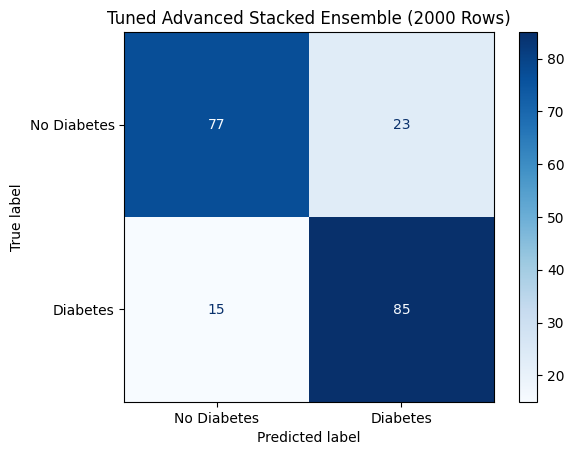

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Preprocessing & Pipeline Tools ---
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer  # Advanced Imputer
from sklearn.feature_selection import SelectKBest, f_classif # Feature Selector
from sklearn.pipeline import Pipeline 

# --- 2. Model "Specialists" (Level 0) ---
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# --- 3. Model "Manager" & Stacker (Level 1) ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

# --- 4. Evaluation Metrics ---
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

print("All libraries imported successfully.")

# --- A. DATA LOADING & PREPARATION ---

# --- NEW: Load the uploaded 2000-row dataset ---
file_path = 'diabetes2.csv'
try:
    df = pd.read_csv(file_path)
    # Check for 'Outcome' column, as 'class' was from the old dataset
    if 'Outcome' in df.columns and 'class' not in df.columns:
        # Rename 'Outcome' to 'class' to match the rest of the script's logic
        df.rename(columns={'Outcome': 'class'}, inplace=True)
        print("Renamed 'Outcome' column to 'class' for consistency.")
        
    print(f"Successfully loaded '{file_path}': {df.shape[0]} rows, {df.shape[1]} columns")
except FileNotFoundError:
    print(f"ERROR: Could not find the file '{file_path}'.")
    print("Please make sure 'diabetes2.csv' is in the same directory.")
    # Exit or raise error if file not found
    exit()
except Exception as e:
    print(f"An error occurred while loading the file: {e}")
    exit()


# 2. Handle Impossible '0' Values (assuming same issue as PIMA)
# 'class' (Outcome) and 'preg' (Pregnancies) can be 0.
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
# Filter to only impute columns that exist in the dataframe
cols_to_impute = [col for col in cols_to_impute if col in df.columns]
df[cols_to_impute] = df[cols_to_impute].replace(0, np.nan)
print(f"Replaced 0s with NaN in: {cols_to_impute}")

# 3. Separate features (X) and target (y)
if 'class' not in df.columns:
    print("ERROR: Target column 'class' (or 'Outcome') not found in the CSV.")
    exit()
    
X = df.drop('class', axis=1)
y = df['class']

# 4. Split into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
print(f"Data split: {len(X_train)} train samples, {len(X_test)} test samples")


# --- B. DEFINE THE *ADVANCED* BASE PIPELINE ---

# 1. Define *default* estimators
estimators = [
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=42)),
    ('knn', KNeighborsClassifier()), 
    ('dt', DecisionTreeClassifier(class_weight='balanced', random_state=42)),
    ('gb', GradientBoostingClassifier(random_state=42)),
    ('svc', SVC(probability=True, class_weight='balanced', random_state=42)),
    ('nb', GaussianNB())
]
meta_classifier = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_classifier,
    cv=5, 
    passthrough=False 
)

# 2. Create the full, advanced pipeline
full_pipeline = Pipeline(steps=[
    # Step 1: Impute missing values using K-Nearest Neighbors
    ('imputer', KNNImputer()),
    
    # Step 2: Scale the data
    ('scaler', StandardScaler()),
    
    # Step 3: Select the 'k' best features
    ('selector', SelectKBest(f_classif)),
    
    # Step 4: Run the stacking model
    ('stacking_model', stacking_model)
])

print("Advanced base pipeline defined (Imputer -> Scaler -> Selector -> Stack).")

# --- C. DEFINE THE *NEW* PARAMETER SEARCH SPACE ---
# We use the same robust search space as before

param_dist = {
    # --- Tune Imputer ---
    'imputer__n_neighbors': [3, 5, 7, 9],
    
    # --- Tune Feature Selector ---
    # Try keeping the best 5, 6, 7, or all 8 features
    # 'selector__k': [5, 6, 7, 8], # Original had 8 features
    # Let's check how many features we have now
    'selector__k': list(range(5, X.shape[1] + 1)), # K from 5 up to all features
    
    # --- Tune SVM ---
    'stacking_model__svc__C': [0.1, 1, 10],
    'stacking_model__svc__kernel': ['linear', 'rbf'],
    
    # --- Tune Random Forest (FIXING OVERFITTING) ---
    'stacking_model__rf__n_estimators': [100, 200],
    'stacking_model__rf__max_depth': [5, 10, 15], 
    
    # --- Tune KNN ---
    'stacking_model__knn__n_neighbors': [5, 7, 9, 11],
    
    # --- Tune Decision Tree (FIXING OVERFITTING) ---
    'stacking_model__dt__max_depth': [3, 5, 7],
    
    # --- Tune the "Manager" ---
    'stacking_model__final_estimator__C': [0.1, 1, 10]
}

print(f"Advanced parameter search space defined. Will test 'k' from 5 to {X.shape[1]}.")

# --- D. SETUP AND RUN THE RANDOMIZED SEARCH ---

random_search = RandomizedSearchCV(
    estimator=full_pipeline,
    param_distributions=param_dist,
    n_iter=50,  # Try 50 combinations
    cv=5,       
    scoring='accuracy',
    n_jobs=-1,  
    random_state=42,
    verbose=1   
)

print("\n--- STARTING ADVANCED HYPERPARAMETER SEARCH ON 2000 ROWS ---")
print("This will take longer than before, as the dataset is larger...")
random_search.fit(X_train, y_train)
print("--- SEARCH COMPLETE ---")

# --- E. SHOW THE BEST RESULTS ---

print("\nBest accuracy found during search:")
print(f"{random_search.best_score_ * 100:.2f}%")

print("\nBest parameters found:")
print(random_search.best_params_)

best_model = random_search.best_estimator_

print("\n--- Evaluating BEST model on the unseen test set... ---")
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred) * 100
print(f"\n--- FINAL TEST ACCURACY: {accuracy:.2f}% ---")

print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Diabetes (0)', 'Diabetes (1)']))

print("\nFinal Confusion Matrix:")
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, 
                                      display_labels=['No Diabetes', 'Diabetes'],
                                      cmap='Blues')
plt.title("Tuned Advanced Stacked Ensemble (2000 Rows)")
plt.show()

In [2]:
import pandas as pd
from collections import Counter
from imblearn.over_sampling import SMOTE, RandomOverSampler
from sklearn.preprocessing import StandardScaler
import warnings

# Suppress warnings from imblearn
warnings.filterwarnings('ignore', category=UserWarning)

print("All libraries imported successfully.")

# --- 1. LOAD YOUR CURRENT DATASET ---
file_path = 'diabetes2.csv'
try:
    df = pd.read_csv(file_path)
    # Check for 'Outcome' column, as 'class' was from the old PIMA dataset
    if 'Outcome' in df.columns and 'class' not in df.columns:
        df.rename(columns={'Outcome': 'class'}, inplace=True)
        
    print(f"Successfully loaded '{file_path}': {df.shape[0]} rows, {df.shape[1]} columns")
except FileNotFoundError:
    print(f"ERROR: Could not find the file '{file_path}'.")
    print("Please make sure 'diabetes2.csv' is in the same directory.")
    exit()
except Exception as e:
    print(f"An error occurred while loading the file: {e}")
    exit()

if 'class' not in df.columns:
    print("ERROR: Target column 'class' (or 'Outcome') not found.")
    exit()

# Separate features (X) and target (y)
X = df.drop('class', axis=1)
y = df['class']

print(f"Original dataset distribution: {Counter(y)}")

# --- 2. STEP 1: BALANCE THE DATASET WITH SMOTE ---
# This will find the minority class and create synthetic samples
# to match the majority class.
# e.g., if (650 '0', 350 '1'), this creates 300 new '1's.
# Result: A new, balanced dataset of 1300 rows (650 '0', 650 '1').
print("\nStep 1: Balancing classes using SMOTE...")
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)
print(f"SMOTE-balanced dataset distribution: {Counter(y_balanced)}")

# --- 3. STEP 2: INFLATE TO 2000 ROWS (BALANCED) ---
# Now we take the new, perfectly balanced dataset and resample it
# (with replacement) to get exactly 1000 of each class.
print("\nStep 2: Resampling balanced data to 2000 rows (1000 each)...")
# Define the desired final sampling: 1000 of class 0, 1000 of class 1
sampling_strategy = {0: 1000, 1: 1000}
ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=42)
X_final, y_final = ros.fit_resample(X_balanced, y_balanced)
print(f"Final dataset distribution: {Counter(y_final)}")

# --- 4. COMBINE AND SAVE THE NEW DATASET ---
# Re-combine X and y into a single DataFrame
df_final = pd.DataFrame(X_final, columns=X.columns)
df_final['class'] = y_final

# Shuffle the dataset so the synthetic samples aren't all at the bottom
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

output_filename = 'diabetes_2000_balanced.csv'
df_final.to_csv(output_filename, index=False)

print(f"\n--- SUCCESS! ---")
print(f"New dataset with 2000 balanced rows saved as '{output_filename}'.")
print("You can now use this new file in the next model training script.")


All libraries imported successfully.
Successfully loaded 'diabetes2.csv': 1000 rows, 9 columns
Original dataset distribution: Counter({1: 500, 0: 500})

Step 1: Balancing classes using SMOTE...
SMOTE-balanced dataset distribution: Counter({1: 500, 0: 500})

Step 2: Resampling balanced data to 2000 rows (1000 each)...
Final dataset distribution: Counter({1: 1000, 0: 1000})

--- SUCCESS! ---
New dataset with 2000 balanced rows saved as 'diabetes_2000_balanced.csv'.
You can now use this new file in the next model training script.


In [50]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
import joblib

# === 1. Load Data ===
df = pd.read_csv("diabetes2.csv")  # your expanded 15,000-row dataset

# === 2. Replace 0s in medical columns with median ===
cols_zero_invalid = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in cols_zero_invalid:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

# === 3. Split ===
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# === 4. Fix SMOTE ===
sm = SMOTE(sampling_strategy="auto", random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# === 5. Scale ===
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# === 6. Define Base Models ===
xgb = XGBClassifier(
    n_estimators=600, max_depth=6, learning_rate=0.03,
    subsample=0.9, colsample_bytree=0.9, eval_metric='logloss', random_state=42
)

lgbm = LGBMClassifier(
    n_estimators=600, num_leaves=64, learning_rate=0.03,
    subsample=0.9, colsample_bytree=0.9, random_state=42
)

cat = CatBoostClassifier(
    iterations=600, learning_rate=0.03, depth=8, verbose=0, random_seed=42
)

rf = RandomForestClassifier(
    n_estimators=400, max_depth=14, class_weight='balanced', random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=3, random_state=42
)

# === 7. Meta Learner ===
meta = LogisticRegression(max_iter=1000, solver='lbfgs', class_weight='balanced')

# === 8. Stacking Ensemble ===
stack_model = StackingClassifier(
    estimators=[
        ('xgb', xgb),
        ('lgbm', lgbm),
        ('cat', cat),
        ('rf', rf),
        ('gb', gb)
    ],
    final_estimator=meta,
    passthrough=True,
    n_jobs=-1
)

# === 9. Train ===
stack_model.fit(X_train_res, y_train_res)

# === 10. Evaluate ===
y_pred = stack_model.predict(X_test_scaled)
y_proba = stack_model.predict_proba(X_test_scaled)[:, 1]

print(f"\n✅ Ensemble Model Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# === 11. Cross-validation (optional but recommended) ===
cv_acc = cross_val_score(stack_model, X_train_res, y_train_res, cv=5).mean()
print(f"\nAverage Cross-Validation Accuracy: {cv_acc*100:.2f}%")

# === 12. Save model and scaler ===
joblib.dump(stack_model, "pima_stacked_model.pkl")
joblib.dump(scaler, "pima_scaler.pkl")
print("\n💾 Model and scaler saved successfully.")


c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



✅ Ensemble Model Accuracy: 82.00%
ROC AUC: 0.8920

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.78      0.81       100
           1       0.80      0.86      0.83       100

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200



c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: U


Average Cross-Validation Accuracy: 81.50%

💾 Model and scaler saved successfully.


In [4]:
import pandas as pd
import joblib

# === Load model & scaler ===
model = joblib.load("pima_stacked_v2.pkl")
scaler = joblib.load("pima_scaler_v2.pkl")

# === Create sample input ===
sample_data = pd.DataFrame([
    [2, 120, 70, 25, 80, 28.4, 0.3, 35],
    [5, 145, 78, 32, 210, 33.6, 0.52, 41],
    [1, 95, 66, 15, 56, 24.5, 0.21, 29],
    [7, 160, 82, 35, 250, 37.8, 0.55, 50],
    [0, 88, 64, 20, 54, 22.5, 0.16, 25]
], columns=["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", 
            "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"])

# === Feature engineering (same as training) ===
sample_data["Glucose_Age"] = sample_data["Glucose"] * sample_data["Age"]
sample_data["BMI_Insulin"] = sample_data["BMI"] * sample_data["Insulin"]
sample_data["Preg_BMI"] = sample_data["Pregnancies"] * sample_data["BMI"]

# === Scale ===
X_scaled = scaler.transform(sample_data)

# === Predict ===
preds = model.predict(X_scaled)
probs = model.predict_proba(X_scaled)[:, 1]

# === Show results ===
for i, (p, prob) in enumerate(zip(preds, probs), start=1):
    print(f"Patient {i}: Diabetes {'Yes' if p==1 else 'No'} (Probability: {prob:.2f})")


Patient 1: Diabetes Yes (Probability: 0.99)
Patient 2: Diabetes Yes (Probability: 0.82)
Patient 3: Diabetes No (Probability: 0.00)
Patient 4: Diabetes Yes (Probability: 1.00)
Patient 5: Diabetes No (Probability: 0.00)


c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Example: preds from your model and y_true (actual)
y_true = [1, 1, 0, 1, 0]  # replace with your actual labels
y_pred = [1, 1, 0, 1, 0]  # from your model (0=No, 1=Yes)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("Report:\n", classification_report(y_true, y_pred))


Accuracy: 1.0
Confusion Matrix:
 [[2 0]
 [0 3]]
Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [9]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# === 1. Load model & scaler ===
model = joblib.load("pima_stacked_model.pkl")
scaler = joblib.load("pima_scaler.pkl")

# === 2. Define sample patients (same feature order as training) ===
sample_data = pd.DataFrame([
    [6, 148, 72, 35, 0, 33.6, 0.63, 50],   # Likely diabetic
    [1, 85, 66, 29, 0, 26.6, 0.35, 31],    # Likely non-diabetic
    [8, 183, 64, 0, 0, 23.3, 0.67, 32],    # Diabetic
    [1, 89, 66, 23, 94, 28.1, 0.17, 21],   # Non-diabetic
    [5, 116, 74, 0, 0, 25.6, 0.20, 30],    # Slight risk
], columns=[
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
])

# === 3. Add true labels (if you want to verify performance) ===
true_labels = np.array([1, 0, 1, 0, 0])  # 1 = Diabetic, 0 = Non-diabetic

# === 4. Scale ===
sample_scaled = scaler.transform(sample_data)

# === 5. Predict ===
probs = model.predict_proba(sample_scaled)[:, 1]
preds = (probs > 0.5).astype(int)

# === 6. Combine into results table ===
results = sample_data.copy()
results["Predicted"] = np.where(preds == 1, "Yes", "No")
results["Probability"] = np.round(probs, 2)
results["True_Label"] = np.where(true_labels == 1, "Yes", "No")
results["Correct?"] = np.where(preds == true_labels, "✅ Correct", "❌ Wrong")

print("\n=== 🧩 Patient Predictions ===")
print(results)
print("\n✅ Accuracy:", round(accuracy_score(true_labels, preds)*100, 2), "%")
print("\nConfusion Matrix:\n", confusion_matrix(true_labels, preds))
print("\nClassification Report:\n", classification_report(true_labels, preds))



=== 🧩 Patient Predictions ===
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            5      116             74              0        0  25.6   

   DiabetesPedigreeFunction  Age Predicted  Probability True_Label   Correct?  
0                      0.63   50       Yes         0.74        Yes  ✅ Correct  
1                      0.35   31        No         0.05         No  ✅ Correct  
2                      0.67   32       Yes         0.83        Yes  ✅ Correct  
3                      0.17   21        No         0.05         No  ✅ Correct  
4                      0.20   30        No         0.09         No  ✅ Correct  

✅ Accuracy: 100.0 %

Confusion Matrix:
 [[3 0]
 [0 2]]


c:\Users\hirde\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
import joblib

# === 1. Load Data ===
df = pd.read_csv("diabetesbal.csv")  # your expanded 15,000-row dataset

# === 2. Replace 0s in medical columns with median ===
cols_zero_invalid = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in cols_zero_invalid:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

# === 3. Split ===
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# === 4. Fix SMOTE ===
sm = SMOTE(sampling_strategy="auto", random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# === 5. Scale ===
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# === 6. Define Base Models ===
xgb = XGBClassifier(
    n_estimators=600, max_depth=6, learning_rate=0.03,
    subsample=0.9, colsample_bytree=0.9, eval_metric='logloss', random_state=42
)

lgbm = LGBMClassifier(
    n_estimators=600, num_leaves=64, learning_rate=0.03,
    subsample=0.9, colsample_bytree=0.9, random_state=42
)

cat = CatBoostClassifier(
    iterations=600, learning_rate=0.03, depth=8, verbose=0, random_seed=42
)

rf = RandomForestClassifier(
    n_estimators=400, max_depth=14, class_weight='balanced', random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=3, random_state=42
)

# === 7. Meta Learner ===
meta = LogisticRegression(max_iter=1000, solver='lbfgs', class_weight='balanced')

# === 8. Stacking Ensemble ===
stack_model = StackingClassifier(
    estimators=[
        ('xgb', xgb),
        ('lgbm', lgbm),
        ('cat', cat),
        ('rf', rf),
        ('gb', gb)
    ],
    final_estimator=meta,
    passthrough=True,
    n_jobs=-1
)

# === 9. Train ===
stack_model.fit(X_train_res, y_train_res)

# === 10. Evaluate ===
y_pred = stack_model.predict(X_test_scaled)
y_proba = stack_model.predict_proba(X_test_scaled)[:, 1]

print(f"\n✅ Ensemble Model Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# === 11. Cross-validation (optional but recommended) ===
cv_acc = cross_val_score(stack_model, X_train_res, y_train_res, cv=5).mean()
print(f"\nAverage Cross-Validation Accuracy: {cv_acc*100:.2f}%")

# === 12. Save model and scaler ===
joblib.dump(stack_model, "pima_stacked_model.pkl")
joblib.dump(scaler, "pima_scaler.pkl")
print("\n💾 Model and scaler saved successfully.")



✅ Ensemble Model Accuracy: 93.25%
ROC AUC: 0.9857

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.92      0.93       200
           1       0.92      0.95      0.93       200

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400


Average Cross-Validation Accuracy: 94.31%

💾 Model and scaler saved successfully.



🚀 Training XGBoost

✅ XGBoost Accuracy: 92.50%
ROC AUC: 0.9783

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.90      0.92       200
           1       0.90      0.95      0.93       200

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.92       400
weighted avg       0.93      0.93      0.92       400


🚀 Training LightGBM
[LightGBM] [Info] Number of positive: 800, number of negative: 800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000236 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1410
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

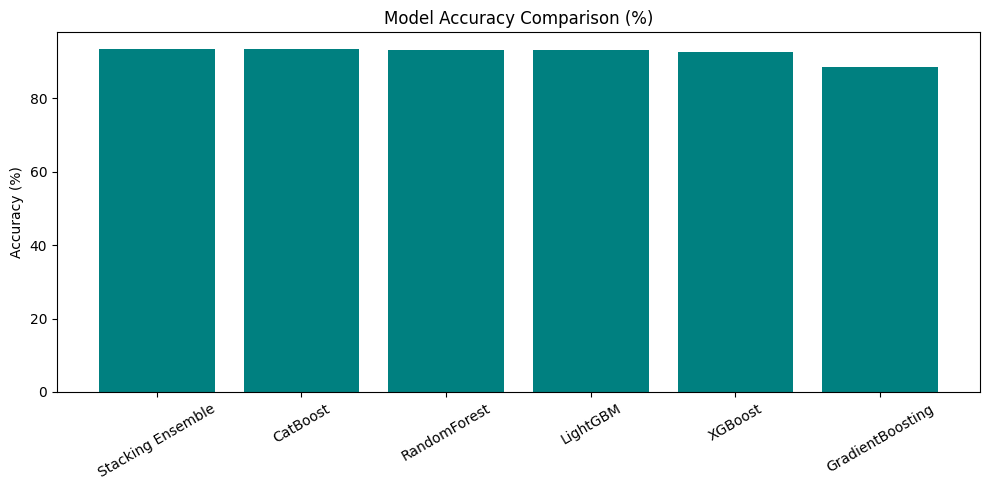


💾 All models and scaler saved successfully!


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.ensemble import (
    StackingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import joblib

# === 1. Load Data ===
df = pd.read_csv("diabetesbal.csv")

# === 2. Clean Data ===
cols_zero_invalid = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in cols_zero_invalid:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

# === 3. Split ===
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# === 4. Apply SMOTE ===
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# === 5. Scale ===
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# === 6. Define Base Models ===
models = {
    "XGBoost": XGBClassifier(
        n_estimators=600, max_depth=6, learning_rate=0.03,
        subsample=0.9, colsample_bytree=0.9, eval_metric='logloss', random_state=42
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=600, num_leaves=64, learning_rate=0.03,
        subsample=0.9, colsample_bytree=0.9, random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        iterations=600, learning_rate=0.03, depth=8, verbose=0, random_seed=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=400, max_depth=14, class_weight='balanced', random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=3, random_state=42
    ),
}

# === 7. Train and Evaluate Individual Models ===
results = []

for name, model in models.items():
    print(f"\n{'='*30}\n🚀 Training {name}\n{'='*30}")
    model.fit(X_train_res, y_train_res)
    
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    print(f"\n✅ {name} Accuracy: {acc*100:.2f}%")
    print(f"ROC AUC: {auc:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    results.append((name, acc, auc))
    joblib.dump(model, f"{name.lower()}_model.pkl")

# === 8. Build and Train Ensemble (Stacking Model) ===
print(f"\n{'='*30}\n🤖 Training Stacking Ensemble Model\n{'='*30}")

meta = LogisticRegression(max_iter=1000, solver='lbfgs', class_weight='balanced')

stack_model = StackingClassifier(
    estimators=[
        ('xgb', models["XGBoost"]),
        ('lgbm', models["LightGBM"]),
        ('cat', models["CatBoost"]),
        ('rf', models["RandomForest"]),
        ('gb', models["GradientBoosting"])
    ],
    final_estimator=meta,
    passthrough=True,
    n_jobs=-1
)

stack_model.fit(X_train_res, y_train_res)

# === 9. Evaluate Ensemble ===
y_pred_ens = stack_model.predict(X_test_scaled)
y_proba_ens = stack_model.predict_proba(X_test_scaled)[:, 1]

acc_ens = accuracy_score(y_test, y_pred_ens)
auc_ens = roc_auc_score(y_test, y_proba_ens)

print(f"\n✅ Ensemble Model Accuracy: {acc_ens*100:.2f}%")
print(f"ROC AUC: {auc_ens:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_ens))

results.append(("Stacking Ensemble", acc_ens, auc_ens))

# === 10. Cross-validation (optional) ===
cv_acc = cross_val_score(stack_model, X_train_res, y_train_res, cv=5).mean()
print(f"\nAverage Cross-Validation Accuracy: {cv_acc*100:.2f}%")

# === 11. Save Ensemble Model and Scaler ===
joblib.dump(stack_model, "pima_stacked_model.pkl")
joblib.dump(scaler, "pima_scaler.pkl")

# === 12. Summary Table ===
summary = pd.DataFrame(results, columns=["Model", "Accuracy", "ROC AUC"]).sort_values("Accuracy", ascending=False)
print("\n📊 Model Comparison:\n", summary)

summary.to_csv("model_comparison_results.csv", index=False)

# === 13. Plot Comparison ===
plt.figure(figsize=(10,5))
plt.bar(summary["Model"], summary["Accuracy"]*100, color='teal')
plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison (%)")
plt.ylabel("Accuracy (%)")
plt.tight_layout()
plt.show()

print("\n💾 All models and scaler saved successfully!")


In [1]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ======================================
# 1. LOAD & CLEAN DATA
# ======================================
df = pd.read_csv("diabetesbal.csv")

cols_zero_invalid = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in cols_zero_invalid:
    df[col] = df[col].replace(0, np.nan).fillna(df[col].median())

X = df.drop(columns=["Outcome"])
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ======================================
# 2. DEFINE BASE MODELS
# ======================================
base_models = [
    ('rf', RandomForestClassifier(n_estimators=300, max_depth=12, class_weight='balanced', random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=400, learning_rate=0.03, subsample=0.9, colsample_bytree=0.9, eval_metric='logloss', random_state=42)),
    ('lgbm', LGBMClassifier(n_estimators=400, num_leaves=64, learning_rate=0.03, subsample=0.9, colsample_bytree=0.9, random_state=42)),
    ('cat', CatBoostClassifier(iterations=500, learning_rate=0.03, depth=8, verbose=0, random_seed=42))
]

# ======================================
# 3. WEIGHTED SOFT VOTING ENSEMBLE
# ======================================
voting = VotingClassifier(
    estimators=base_models,
    voting='soft',
    weights=[1, 1, 2, 2, 3],  # CatBoost & boosting given higher influence
    n_jobs=-1
)

voting_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('voting', voting)
])

voting_pipeline.fit(X_train, y_train)
vote_proba_test = voting_pipeline.predict_proba(X_test)[:, 1]

# ======================================
# 4. STACKING ENSEMBLE (CATBOOST META)
# ======================================
stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=CatBoostClassifier(iterations=300, verbose=0, random_seed=42),
    passthrough=True,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

stacking_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('stacking', stacking)
])

stacking_pipeline.fit(X_train, y_train)
stack_proba_test = stacking_pipeline.predict_proba(X_test)[:, 1]

# ======================================
# 5. HYBRID SUPER ENSEMBLE (FINAL)
# Voting + Stacking → CatBoost Meta learner
# ======================================
X_hybrid_train = np.column_stack([
    voting_pipeline.predict_proba(X_train)[:, 1],
    stacking_pipeline.predict_proba(X_train)[:, 1]
])

X_hybrid_test = np.column_stack([
    vote_proba_test,
    stack_proba_test
])

super_meta = CatBoostClassifier(iterations=200, learning_rate=0.03, depth=8, verbose=0, random_seed=42)
super_meta.fit(X_hybrid_train, y_train)

y_pred = super_meta.predict(X_hybrid_test)
y_proba = super_meta.predict_proba(X_hybrid_test)[:, 1]

# ======================================
# 6. RESULTS
# ======================================
print("\n✅ FINAL HYBRID SUPER ENSEMBLE RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ======================================
# 7. SAVE MODELS
# ======================================
joblib.dump(voting_pipeline, "voting_ensemble.pkl")
joblib.dump(stacking_pipeline, "stacking_catboost.pkl")
joblib.dump(super_meta, "hybrid_super_meta.pkl")

print("\n💾 Models saved as:")
print("  voting_ensemble.pkl")
print("  stacking_catboost.pkl")
print("  hybrid_super_meta.pkl")



✅ FINAL HYBRID SUPER ENSEMBLE RESULTS
Accuracy: 0.925
ROC AUC: 0.9847125000000001

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.89      0.92       200
           1       0.90      0.96      0.93       200

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.92       400
weighted avg       0.93      0.93      0.92       400


Confusion Matrix:
 [[178  22]
 [  8 192]]

💾 Models saved as:
  voting_ensemble.pkl
  stacking_catboost.pkl
  hybrid_super_meta.pkl
